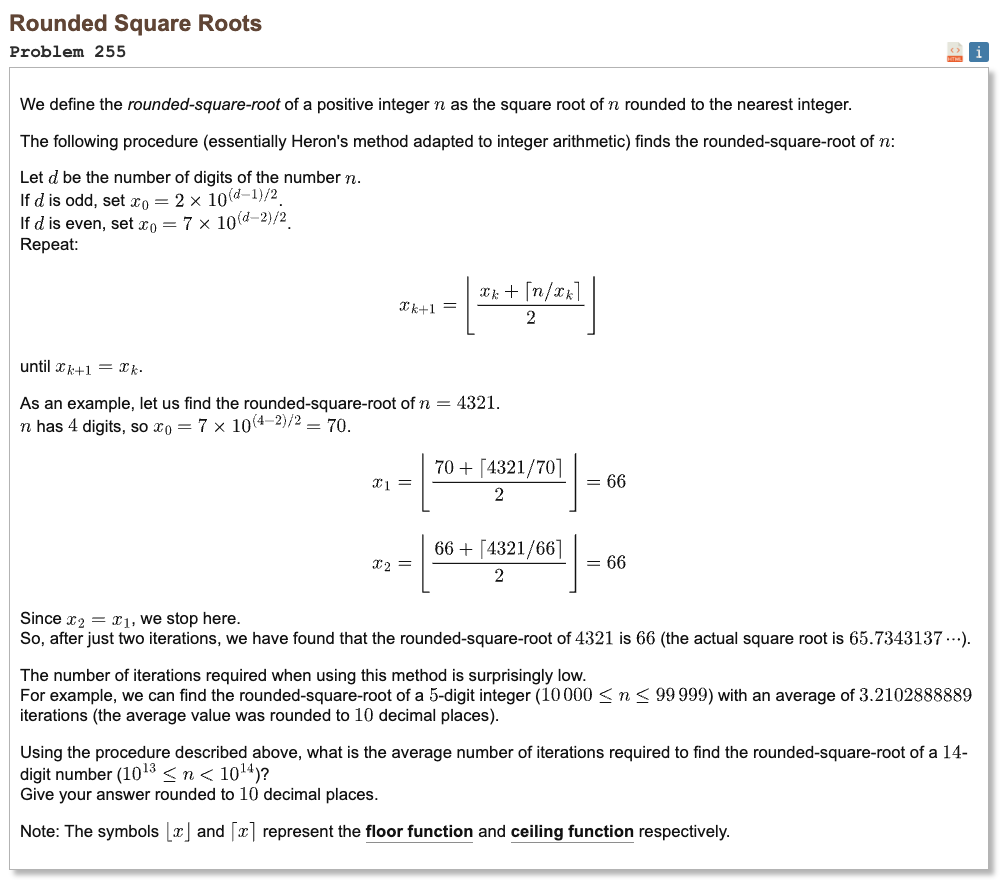

## Initial approach

* we do not test every 14 digit number because there are too many
* the iteration only depends on the size of n, not on its exact digits
* the starting guess is chosen from the number of digits of n
* each step replaces x by the integer average of x and n divided by x
* the process stops when x does not change anymore
* group numbers by ranges where the iteration count behaves the same
* count how many numbers in each range need k steps, then compute the weighted average
* round the final average to 10 decimal places

In [1]:
from math import floor

LOW = 10**13
HIGH = 10**14 - 1

def iterate_count(n):
    d = len(str(n))
    if d % 2 == 1:
        x = 2 * 10**((d - 1) // 2)
    else:
        x = 7 * 10**((d - 2) // 2)

    count = 0
    while True:
        count += 1
        nx = (x + n // x) // 2
        if nx == x:
            return count
        x = nx

def solve():
    total_iterations = 0
    total_numbers = HIGH - LOW + 1

    step = 100000
    n = LOW
    while n <= HIGH:
        k = iterate_count(n)
        total_iterations += k * min(step, HIGH - n + 1)
        n += step

    average = total_iterations / total_numbers
    print("Result:", f"{average:.10f}")

Note: performance optimization will follow.